<img src="starting_point.jpg" width="800">

Notebook for using the Surrounding self-energies for later use in the project.
Based on [Alan's notebook](../../resources/SE_Graphene_Example-TB.ipynb)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sea
import numpy as np
import sisl
from sisl import Hamiltonian
import ase
from ase.visualize import view
from tqdm.auto import tqdm
from SE_utils import loop_GF

# Create basis for pristine graphene layer (primitive unit cell)

In [3]:
bond = 1.43
gr = sisl.geom.graphene(bond, "C")
gr.plot(axes="xy")

# Make hamiltonian

In [4]:
Ham0 = Hamiltonian(gr)
print(Ham0)

Hamiltonian{non-zero: 0, orthogonal: True,
 Spin{unpolarized},
 Geometry{na: 2, no: 2,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01070, maxR: -1.00000,
    Orbital{R: -1.00000, q0: 0.0}
   }: 2,
  },
  maxR: -1.00000,
  Lattice{nsc: [3 3 1],
   origin=[0.0000, 0.0000, 0.0000],
   A=[2.1450, -1.2384, 0.0000],
   B=[2.1450, 1.2384, 0.0000],
   C=[0.0000, 0.0000, 20.0000],
   bc=[Periodic,
       Periodic,
       Unknown]
  }
 }
}


# Define TB

In [5]:
bond = 1.43
R = np.array([0.1*bond, bond+0.01])

for ia in gr:
    idx_a = gr.close(ia, R)
    Ham0[ia, idx_a[0]] = 0.
    Ham0[ia, idx_a[1]] = -2.7

# r = (0.1, 1.44)
# t = (0, -2.7)
# Ham0.construct([r, t])
print(Ham0.Hk(format="array"))

[[ 0.  -8.1]
 [-8.1  0. ]]


In [6]:
Ham = Ham0.tile(1,0).tile(1,1)

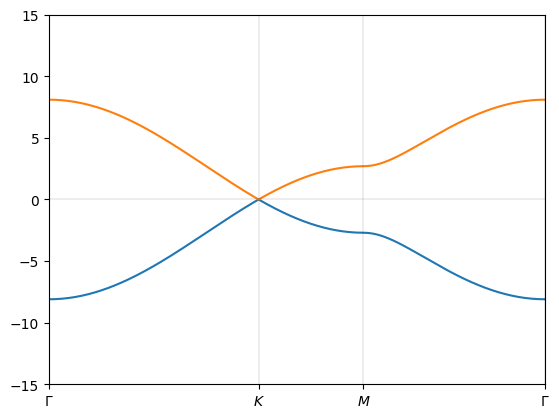

In [7]:
band = sisl.BandStructure(Ham, points= [[0., 0., 0.], [1 / 3, 2 / 3, 0], [0, 0.5, 0],[0., 0., 0.]],divisions= 300, names=[r'$\Gamma$', r"$K$", r"$M$",r'$\Gamma$'])
lineark, kticks, klabels = band.lineark(True)

fig, ax = plt.subplots()

bs = np.empty(shape=(len(band),2))
for ik, eigh in enumerate(band.apply.eigh()):
    bs[ik] = eigh

ax.plot(lineark, bs, label="TB")
for tick in kticks:
    ax.axvline(x=tick, lw=0.1, color="k")
ax.set(xlim=(kticks[0], kticks[-1]), ylim=(-15, 15))
ax.axhline(y=0, color="k", lw=0.1)
ax.set_xticks(kticks)
ax.set_xticklabels(klabels)

None

# Make Real-space self-energy by tiling (this is surrounding self-energies)?

In [8]:
Na, Nb = 12, 12
nk1 = int(np.ceil(1e3/Na))
eta = 1e-3j
rse = sisl.RealSpaceSE(Ham, 0, 1, unfold=(Na, Nb, 1))
rse.setup(eta=eta, bz=sisl.MonkhorstPack(Ham, [1, nk1, 1]))

In [11]:
# from pathlib import Path
# Path("./TBT").mkdir(parents=False, exist_ok=True)

H_elec, elec_indices = rse.real_space_coupling(ret_indices=True)
# H_elec.write("TBT/elec.nc")
# !tree -L 2 # run bash terminal command
# H_elec.geometry.plot(axes="xy")

# Tile the primitive unit cell hamiltonian

In [12]:
HamNN = Ham.tile(Na, 0).tile(Nb,1)
HamNN.set_nsc([1,1,1]) # remove PBC
geomNN = HamNN.geometry
geomNN.plot(axes="xy")

# Remove from the device if part of the electrode

In [13]:
all_atoms = np.arange(0, geomNN.na)
inside_atoms = np.delete(all_atoms, elec_indices)
Ham_inside = HamNN.sub(inside_atoms)
Ham_inside.geometry.plot(axes="xy")

In [15]:
from sisl.viz import merge_plots
plots = [
    Ham_inside.geometry.plot(axes="xy", atoms_style={"color":"black"}), # the device atoms
    H_elec.geometry.plot(axes="xy", atoms_style=({"color":"red"}))
]
merge_plots( *plots, composite_method="multiple"
)

# View atoms to show atom index labels before reordering

In [16]:
# view(HamNN.geometry.to.ase())
# view(Ham_inside.geometry.to.ase())

# Reorder atoms

In [13]:
alist = np.concatenate([elec_indices, inside_atoms])
HamNN_reorder = HamNN.sub(alist)
HamNN_reorder.set_nsc([1,1,1]) # reomve PBC
HamNN_reorder.write('TBT/device.nc')

# View the reordered atoms

In [ ]:
view(HamNN_reorder.geometry.to.ase())

# The TB calculation in SISL (and a `.TBTGF`-file?)

In [ ]:
# import time

# eta = 1e-3j
# Emax = 3
# Emin = -Emax
# dE = 1e-2
# E = np.arange(Emin, Emax+dE, dE)

# bz = sisl.BrillouinZone(H_elec)
# t0 = time.time()
# with sisl.io.tbtgfSileTBtrans("TBT/graphene.TBTGF") as file:
#     file.write_header(bz, E + eta)
#     for ispin, new_k, k, e in tqdm(file):
#         if new_k:
#             H = H_elec.Hk(format='array', dtype=np.complex128)
#             S = H_elec.Sk(format='array', dtype=np.complex128)
#             file.write_hamiltonian(H, S)
#         RSE = rse.self_energy(e + eta, bulk=True, coupling=True)
#         file.write_self_energy(RSE)

# print(f"procedure took {time.time() - t0:.3f} s")

  0%|          | 0/601 [00:00<?, ?it/s]

procedure took 237.127 s


In [ ]:
# with open("TBT/tbt.fdf", 'w') as file:  
#     file.write(
#         """
#         SystemName        graphene
#         SystemLabel       graphene

#         # ---------- Hamiltonian ----------
#         TBT.HS Device.nc

#         #---------- Electrode ----------
#         %block TS.Elecs
#             Elec
#         %endblock TS.Elecs

#         %block TS.Elec.Elec
#             HS Elec.nc
#             semi-inf-direction  abc 
#             electrode-position 1
#             Out-of-core true
#             tbt.Gf      graphene.TBTGF
#         %endblock 

#         # ---------- k-point sampling ----------
#         TBT.k [1 1 1]

#         # ---------- Contour line ----------
#         %block TBT.Contour.line
#         part line
#             from -3 eV to 3 eV
#             file contour.E 
#         %endblock TBT.Contour.line

#         # ---------- Output ----------
#         TBT.DOS.A
#         TBT.DOS.Gf
#         TBT.Current.Orb
#         """
#        )

In [ ]:
# !ls TBT/ -l

total 20068
-rw-r--r-- 1 bastian bastian    59858 Feb 16 10:21 device.nc
-rw-r--r-- 1 bastian bastian    28048 Feb 16 10:21 elec.nc
-rw-r--r-- 1 bastian bastian 20450372 Feb 16 10:25 graphene.TBTGF
-rw-r--r-- 1 bastian bastian      831 Feb 16 10:25 tbt.fdf


# sisl calculations

In [17]:
print(Ham)
# print(HamNN_reorder.nsc)
# print(HamNN_reorder)

Hamiltonian{non-zero: 8, orthogonal: True,
 Spin{unpolarized},
 Geometry{na: 2, no: 2,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01070, maxR: -1.00000,
    Orbital{R: -1.00000, q0: 0.0}
   }: 2,
  },
  maxR: -1.00000,
  Lattice{nsc: [3 3 1],
   origin=[0.0000, 0.0000, 0.0000],
   A=[2.1450, -1.2384, 0.0000],
   B=[2.1450, 1.2384, 0.0000],
   C=[0.0000, 0.0000, 20.0000],
   bc=[Periodic,
       Periodic,
       Unknown]
  }
 }
}


In [20]:
# eta = 1e-3j
# dE = 0.1
# Emax = 3
# Emin = -Emax
# energies = np.arange(Emin, Emax + dE, dE)
# nk1 = int(np.ceil(3*900/Nb))


# rse = sisl.RealSpaceSE(Ham, 0, 1, (Na, Nb, 1))
# rse.setup(eta=abs(eta), bz=sisl.MonkhorstPack(Ham, [1, nk1, 1]))
# _, elec_indices = rse.real_space_coupling(geomNN)
# nC = len(elec_indices)


# recreate the same hamiltonian (debugging)
# HamNN = Ham.tile(Na,0).tile(Nb,1)
# geomNN = HamNN.geometry
# HamNN.set_nsc([1,1,1])
# geomNN = HamNN.geometry

# all_atoms = np.arange(0, HamNN.na)
# inside_atoms = np.delete(all_atoms, elec_indices, axis=0)
# alist = np.concatenate([elec_indices, inside_atoms])

# HamNN_reorder = HamNN.sub(alist)
# HamNN_reorder.reduce()


# H_sub = HamNN_reorder.Hk(format="array")   
# S_sub= HamNN_reorder.Sk(format="array")

In [21]:
Ham.Sk(format="array")

array([[1., 0.],
       [0., 1.]])

In [ ]:
# nk1

84

In [23]:
eta = 0.001* 1j
dE=0.1
Emax = 3.0
Emin = -Emax
energies = np.array([-0.5, 0.01, +0.05])

# Real Space Self Energies
N0 = 12
N1 = 12
nk1 = int(np.ceil(3*900/N1))

rse = sisl.RealSpaceSE(Ham, 0, 1, (N0, N1, 1))
rse.setup(eta= 0.001, bz=sisl.MonkhorstPack(Ham, [1, nk1, 1]))
elec_indices = rse.real_space_coupling(geomNN)[1]
nC = len(elec_indices)   # number of coupling atoms

# Hamiltonian Self Energy
HamNN=Ham.tile(N0,0).tile(N1,1)
geomNN = HamNN.geometry
HamNN.set_nsc([1,1,1]) # remove al pbc
geomNN = HamNN.geometry

# indexes sort
all_atoms=np.arange(0,HamNN.na)
inside_atoms = np.delete(all_atoms, elec_indices, axis=0)
alist = np.concatenate([elec_indices, inside_atoms])

# Reordering Hamiltonain
HamNN_reorder=HamNN.sub(alist)
HamNN_reorder.reduce()
HamNN_reorder.set_nsc([1,1,1]) # remove al pbc
H_sub = HamNN_reorder.Hk(format="array")   
S_sub= HamNN_reorder.Sk(format="array")

In [23]:
# def calc_GF(E,eta,rse,H_sub,S_sub,alist=None):
#     z = E +  eta
#     A = z*S_sub - H_sub 
#     RSE = rse.self_energy(z)
#     if alist is not None:
#         RSE = RSE[np.ix_(alist, alist)]
#         A[0:len(alist),0:len(alist)] -= RSE  
#     else: 
#         A -= RSE
#     G = np.linalg.inv(A)   
#     dos = - (1.0 / np.pi) * np.imag(np.trace(G@S_sub)) 
#     ldos = - (1.0 / np.pi) * np.imag(np.diag(G@S_sub))
#     return dos, ldos

# def loop_GF(energies,eta,rse,H_sub,S_sub,alist=None):
#     # Observables
#     N = H_sub.shape[0]
#     DOS = np.zeros_like(energies, dtype=float)
#     LDOS = np.zeros((N, len(energies)), dtype=float)  

#     # Loop
#     for iE, E in enumerate(tqdm(energies, desc='DOS')):
#         dos,ldos =calc_GF(E,eta,rse,H_sub,S_sub,alist=alist)
#         DOS[iE] = dos
#         LDOS[:,iE] = ldos
#     return DOS, LDOS

In [25]:
import time

In [26]:
t0 = time.perf_counter()
DOS, LDOS = loop_GF(energies,eta,rse,H_sub,S_sub,alist=alist)
t1 = time.perf_counter()
print(f"Total runtime: {t1 - t0:.2f} seconds")
print(f"Time per energy: {(t1 - t0)/len(energies):.4f} s")
LDOS_dev= LDOS[nC:,:]
DOS_dev = LDOS_dev.sum(axis=0)  

DOS: 100%|██████████| 3/3 [00:02<00:00,  1.12it/s]

Total runtime: 2.69 seconds
Time per energy: 0.8982 s


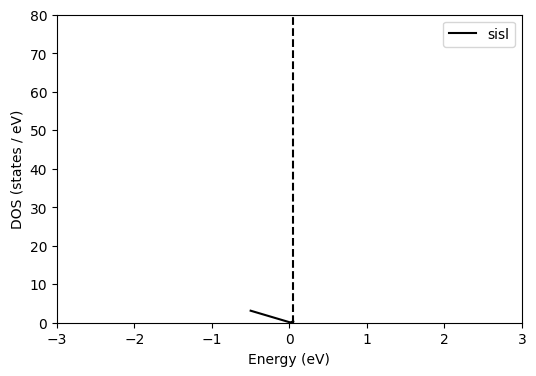

In [31]:
# === plot DOS ===
E_idx=30
E_idx=min(E_idx, len(energies)) -1
plt.figure(figsize=(6,4))
#plt.plot(tbt.E, tbt.DOS(), lw=1.5,c='r',label='TBT')
plt.plot(energies,DOS_dev,c='k',label='sisl')
plt.xlabel("Energy (eV)")
plt.ylabel("DOS (states / eV)")
plt.vlines(x=energies[E_idx],ymin=0,ymax=600,color='k',linestyle='dashed')
plt.ylim(0,80)
plt.xlim(-3,3)
plt.legend()
plt.show()